<a href="https://colab.research.google.com/github/nam-hoang-le/Traffic-Sign-Detection/blob/le-hoang-nam/Traffic_Sign_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# object detection = classfication + localization

In [ ]:
import time
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from skimage.transform import resize
from skimage import feature
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# YOLO format: (x_center, y_center, width, height)
# Pascal VOC format: (xmin, ymin, xmax, ymax)
# (top left, bottom, right)
# change format

In [ ]:
# draw bounding box
# cv2.rectangle()

In [ ]:
# crop object function

In [ ]:
# confidence score

In [ ]:
# Object Classification
# SVM

In [ ]:
annotations_dir = '/content/drive/MyDrive/traffic_sign_detection/annotations'
img_dir = '/content/drive/MyDrive/traffic_sign_detection/images'
img_lst = []
label_lst = []

In [ ]:
# take file path
# listdir(): run all the files in folder
for xml_file in os.listdir(annotations_dir):

    # create file path to annotations_dir
    xml_filepath = os.path.join(annotations_dir, xml_file)

    # take the root
    tree = ET.parse(xml_filepath)

    # create a root
    root = tree.getroot()

    # read image file
    # folder in xml
    folder = root.find('folder').text

    # filename in xml
    img_filename = root.find('filename').text

    # create file path to img_filename
    img_filepath = os.path.join(img_dir, img_filename)

    # read image
    img = cv2.imread(img_filepath)

    # find all object
    for obj in root.findall('object'):

        # find classname
        classname = obj.find('name').text

        # ignore traffic light
        if classname == 'trafficlight':
            continue

        # take the information about the image and slice the object
        xmin = int(obj.find('bndbox/xmin').text)
        ymin = int(obj.find('bndbox/ymin').text)
        xmax = int(obj.find('bndbox/xmax').text)
        ymax = int(obj.find('bndbox/ymax').text)

        object_img = img[ymin:ymax, xmin:xmax]
        img_lst.append(object_img)
        label_lst.append(classname)

In [ ]:
# check data
print('Number of objects: ', len(img_lst))
print('Class names: ', list(set(label_lst)))

Number of objects:  1074
Class names:  ['crosswalk', 'speedlimit', 'stop']


In [ ]:
print('Image shape:')
print(img_lst[1].shape)

Image shape:
(187, 197, 3)


In [ ]:
flattened_img = img_lst[1].flatten()
print('Image shape after flattened:')
print(flattened_img.shape)

Image shape after flattened:
(110517,)


In [ ]:
# Image Preprocessing using HoG
# Gradient Magnitude (ma trận độ lớn)
# Gradient Direction (ma trận phương)
# convolution

In [ ]:
# image preprocessing
# HoG(Histogram of Oriented Gradients)
# feature.hog()

def preprocess_img(img):
    # change to greyscale
    if len(img.shape) >2:
        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )
    # chage to float32
    img = img.astype(np.float32)

    # change size
    resized_img = resize(
        img,
        output_shape = (32,32),
        anti_aliasing = True
    )

    # change to HoG representation
    hog_feature = feature.hog(
        resized_img,
        orientations =9,
        pixels_per_cell =(8 , 8) ,
        cells_per_block =(2 , 2) ,
        transform_sqrt =True ,
        block_norm ="L2",
        feature_vector = True
    )
    return hog_feature

In [ ]:
img_features_lst = []
for img in img_lst:
    hog_feature = preprocess_img(img)
    img_features_lst.append(hog_feature)
img_features = np.array(img_features_lst)
print('X shape: ')
print(img_features.shape)

X shape: 
(1074, 324)


In [ ]:
print(img_features.shape)

(1074, 324)


In [ ]:
print('Shape of the first image before preprocessing: ', img_lst[0].shape)
print('Shape of the first image after preprocessing: ', img_features[0].shape)

Shape of the first image before preprocessing:  (331, 296, 3)
Shape of the first image after preprocessing:  (324,)


In [ ]:
# encode label

In [ ]:
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(label_lst)

In [ ]:
label_encoder.classes_

array(['crosswalk', 'speedlimit', 'stop'], dtype='<U10')

In [ ]:
encoded_labels

array([1, 1, 1, ..., 1, 1, 2])

In [ ]:
# create train, val set

In [ ]:
random_state = 0
test_size = 0.3
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    img_features, encoded_labels,
    test_size = test_size,
    random_state = random_state,
    shuffle = is_shuffle
)

In [ ]:
# normalization

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [ ]:
X_train

array([[ 1.5140715 ,  1.2615715 , -0.0548248 , ..., -0.5168836 ,
        -0.27782997, -0.19653523],
       [ 1.6625832 , -1.4370592 , -1.4947661 , ..., -0.29297048,
        -0.52865916,  0.04436341],
       [-0.8027518 , -1.0763065 ,  0.06586514, ...,  0.26700985,
        -0.18448207, -0.53444886],
       ...,
       [ 1.8703233 , -1.0009207 , -1.56244   , ...,  0.26164824,
        -0.22946814, -0.4223618 ],
       [-0.06088883,  0.07823804, -0.26369455, ...,  0.3635189 ,
        -0.48400217,  0.09931087],
       [ 1.0832558 ,  3.6629303 ,  0.34723282, ..., -0.563479  ,
        -0.52865916, -0.58266854]], dtype=float32)

In [ ]:
# training SVM

In [ ]:
clf = SVC(
    kernel = 'rbf',
    random_state = random_state,
    # take the result not by ID
    probability = True,
    C = 0.5
)
clf.fit(X_train, y_train)

SVC(C=0.5, probability=True, random_state=0)

In [ ]:
# Evaluation

In [ ]:
y_pred = clf.predict(X_val)
score = accuracy_score(y_pred, y_val)

print('Evaluation results on val set')
print('Accuracy:', score)

Evaluation results on val set
Accuracy: 0.9845201238390093


In [ ]:
# confidence score
input_img = img_lst[1]
normalized_img = preprocess_img(input_img)
y_pred = clf.predict([normalized_img])[0]
print(f'Normal prediction: {y_pred}')

# take the result with the list of probability results
y_pred_prob = clf.predict_proba([normalized_img])

# take the highest probability
prediction = np.argmax(y_pred_prob)

y_pred_prob = [f'{p:.10f}' for p in y_pred_prob[0]]
print(f'Probability of each class: {y_pred_prob}')
print(f'Class with highest probability: {prediction}')

Normal prediction: 1
Probability of each class: ['0.0000000002', '0.9999841508', '0.0000158490']
Class with highest probability: 1


In [ ]:
# Object Localization
# Pyramid Images
# Sliding window technique
# Non-maximum Suppression

In [ ]:
# Sliding windows -> bbox
# Computer Vision and Signal Processing
# create a fixed window then move through all the picture
# then we take all the window out
# greedy algorithm
# disadvantage: fixed size for all the images

# stride: window moving, window size
# diploma: performance and accuracy

In [ ]:
def sliding_window(img, window_sizes, stride, scale_factor):
  img_height, img_width = img.shape[:2]
  windows = []
  for window_size in window_sizes:
    window_width, window_height = window_size
    for ymin in range(0, img_height-window_height +1, stride):
      for xmin in range(0, img_width - window_width +1, stride):
        xmax = xmin + window_width
        ymax = ymin + window_height

        windows.append([xmin, ymin, xmax, ymax])
  return windows

In [ ]:
# small objects problem -> pyramid images
# smaller scale

def pyramid(img, scale = 0.8, min_size = (30,30)):
  acc_scale = 1.0 # accumulated scale: tích lũy
  pyramid_imgs = [(img, acc_scale)]

  i = 0
  while True:
    acc_scale = acc_scale * scale
    h = int(img.shape[0] * acc_scale)
    w = int(img.shape[1] * acc_scale)
    if h < min_size[1] or w < min_size[0]:
      break
    img = cv2.resize(img, (w,h))
    pyramid_imgs.append((img, acc_scale * (scale **i)))
    i+=1

  return pyramid_imgs

In [ ]:
# visualize bounding box

In [ ]:
def visualize_bbox(img, bboxes, label_encoder):
  # switch to RGB
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  for box in bboxes:
    xmin, ymin, xmax, ymax, predict_id, conf_score = box

    #draw bounding box
    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0,255,0), 2)

    classname = label_encoder.inverse_transform([predict_id])[0]
    # print label + confidence score
    label = f"{classname}{conf_score:.2f}"

    # print higher box
    (w,h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)

    cv2.rectangle(img, (xmin, ymin -20), (xmin + w, ymin), (0,255, 0), -1)

    cv2.putText(img, label, (xmin, ymin -5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 1)

    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [ ]:
# Non-maximum Suppression (NMS)
# remove non-maximum score, keep only the highest one
# IoU function (percentage intersect between two bounding boxes)
# fix the duplicated images

In [ ]:
# iou function
def compute_iou(bbox, bboxes, bbox_area, bboxes_area):
    xxmin = np.maximum(bbox[0], bboxes[:, 0])
    yymin = np.maximum(bbox[1], bboxes[:, 1])
    xxmax = np.maximum(bbox[2], bboxes[:, 2])
    yymax = np.minimum(bbox[3], bboxes[:,3])

    w = np.maximum(0, xxmax -xxmin +1)
    h = np.maximum(0, yymax - yymin +1)
    intersection = w+h
    iou = intersection / (bbox_area + bboxes_area - intersection)

    return iou

In [ ]:
# IoU threshold

In [ ]:
def nms(bboxes, iou_threshold):
    if not bboxes:
        return []

    # sort in order confidence score
    scores = np.array([bbox[5] for bbox in bboxes])
    sorted_indices = np.argsort(scores)[::-1]

    # calculate bbox area
    xmin = np.array([bbox[0] for bbox in bboxes])
    ymin = np.array([bbox[1] for bbox in bboxes])
    xmax = np.array([bbox[2] for bbox in bboxes])
    ymax = np.array([bbox[3] for bbox in bboxes])

    areas = (xmax - xmin +1) * (ymax - ymin +1)

    keep = []
    while sorted_indices.size > 0:
        i = sorted_indices[0] # highest confidence score
        keep.append(i)

        iou = compute_iou(
            [xmin[i], ymin[i], xmax[i], ymax[i]],
            np.array(
                [
                    xmin[sorted_indices[1:]],
                    ymin[sorted_indices[1:]],
                    xmax[sorted_indices[1:]],
                    ymax[sorted_indices[1:]]]
            ).T,
            areas[i],
            areas[sorted_indices[1:]]
        )

        idx_to_keep = np.where(iou <= iou_threshold)[0]
        sorted_indices = sorted_indices[idx_to_keep + 1]

    return [bboxes[i] for i in keep]

In [ ]:
# Training

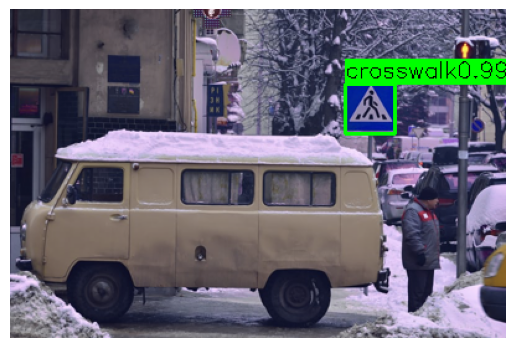

Time process: 7.633405923843384


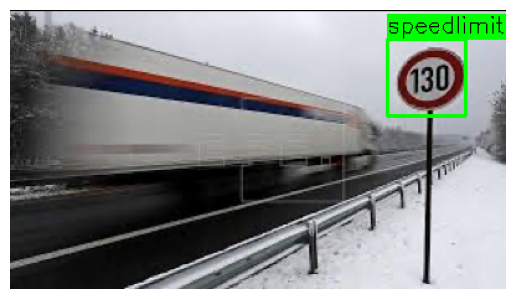

Time process: 3.6149535179138184


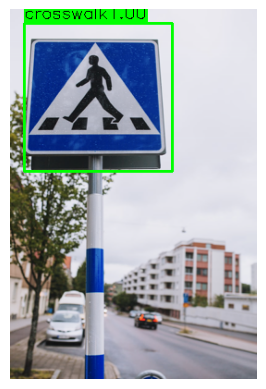

Time process: 3.506847381591797


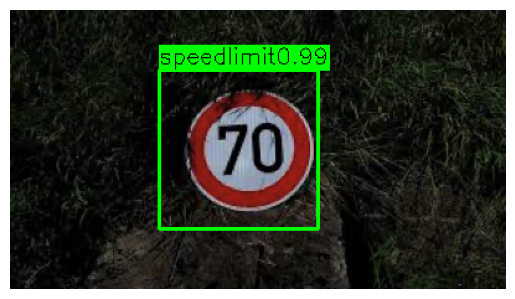

Time process: 2.8343324661254883


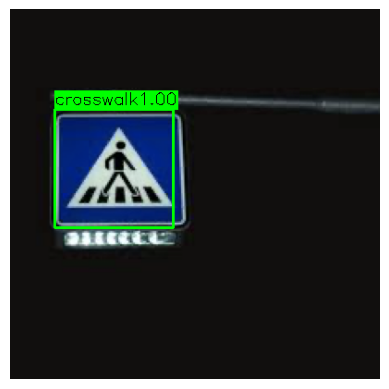

Time process: 6.062322616577148


In [ ]:
# show the file path and variable to fix the result
img_dir = '/content/drive/MyDrive/traffic_sign_detection/images'
img_filename_lst = os.listdir(img_dir)[20:40]
conf_threshold = 0.99
iou_threshold = 0.001
stride = 12
window_sizes = [
    (32,32),
    (64, 64),
    (128, 128)
]
for img_filename in img_filename_lst:
    start_time = time.time()
    img_filepath = os.path.join(img_dir, img_filename)
    bboxes = []
    img = cv2.imread(img_filepath)
    pyramid_imgs = pyramid(img)
    # prediction
    for pyramid_img_info in pyramid_imgs:
        pyramid_img, scale_factor = pyramid_img_info
        window_lst = sliding_window(
            pyramid_img,
            window_sizes = window_sizes,
            stride = stride,
            scale_factor = scale_factor
        )
        for window in window_lst:
            xmin, ymin, xmax, ymax = window

            # slide pyramid image
            object_img = pyramid_img[ymin:ymax, xmin:xmax]

            # preprocessing process
            preprocessed_img = preprocess_img(object_img)

            # normalize image
            normalized_img = scaler.transform([preprocessed_img])[0]

            # use svm to predict
            decision = clf.predict_proba([normalized_img])[0]

            # confidence threshold
            if np.all(decision < conf_threshold):
                continue
            else:
                # take the highest probability = prediction
                predict_id = np.argmax(decision)

                # confidence score = highest probability
                conf_score = decision[predict_id]

                # scale up the window
                xmin = int(xmin / scale_factor)
                ymin = int(ymin/scale_factor)
                xmax = int(xmax / scale_factor)
                ymax = int(ymax / scale_factor)
                bboxes.append(
                    [xmin, ymin, xmax, ymax, predict_id, conf_score]
                )
    bboxes = nms(bboxes, iou_threshold)
    visualize_bbox(img, bboxes, label_encoder)
    if bboxes and visualize_bbox:
        print(f'Time process:', time.time() - start_time)